# Network Intrusion Detection
### Machine Learning Course Project

**Dataset:** NSL-KDD (`KDDTrain+.txt` / `KDDTest+.txt`)  
**Date:** May 2026

---

## Overview
This notebook implements a complete machine learning pipeline for network intrusion detection using the NSL-KDD dataset. The goal is to classify network connections into five categories: normal traffic and four attack types (DoS, Probe, R2L, U2R). Four models are trained and evaluated: Random Forest, XGBoost, Isolation Forest, and a Multi-Layer Perceptron (MLP). Models are benchmarked on accuracy, Macro F1, training time, and inference latency.

> **Reproducibility:** All random states are fixed to `SEED = 42`. To reproduce all results, run all cells from top to bottom without modification. Dataset files (`KDDTrain+.txt`, `KDDTest+.txt`) must be placed in the same directory as this notebook.

## 1. Imports

All required libraries are imported here. Key dependencies:
- `scikit-learn` — preprocessing, Random Forest, Isolation Forest, metrics
- `xgboost` — gradient boosting classifier
- `imbalanced-learn` — SMOTE for class balancing
- `torch` — MLP implementation
- `pandas / numpy / matplotlib / seaborn` — data handling and visualization

Install all dependencies via: `pip install pandas numpy matplotlib seaborn scikit-learn imbalanced-learn xgboost torch ipykernel`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    classification_report, confusion_matrix
)
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import time
import warnings
warnings.filterwarnings('ignore')

# Fix all random seeds for reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

print('All imports successful.')
print(f'PyTorch version: {torch.__version__}')
print(f'Device: {"cuda" if torch.cuda.is_available() else "cpu"}')

All imports successful.
PyTorch version: 2.11.0+cu130
Device: cpu


## 2. Data Ingestion

The NSL-KDD dataset is a refined version of the KDD Cup 1999 dataset, designed to address several inherent problems such as duplicate records. It contains 41 features describing network connection properties, plus a label column and a difficulty score.

The 41 features cover:
- **Basic features:** duration, protocol type, service, bytes transferred
- **Content features:** number of failed logins, root shell access, file creations
- **Traffic features:** connection counts, error rates, same-service rates
- **Host-based features:** destination host connection statistics

Since the dataset files have no header row, column names are supplied manually based on the official NSL-KDD documentation. An assertion checks column count immediately after loading to catch any silent misalignment.

In [2]:
columns = [
    'duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes', 'land',
    'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in',
    'num_compromised', 'root_shell', 'su_attempted', 'num_root',
    'num_file_creations', 'num_shells', 'num_access_files', 'num_outbound_cmds',
    'is_host_login', 'is_guest_login', 'count', 'srv_count', 'serror_rate',
    'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate',
    'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count',
    'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate',
    'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate',
    'dst_host_rerror_rate', 'dst_host_srv_rerror_rate',
    'label', 'difficulty'
]

train_df = pd.read_csv('KDDTrain+.txt', names=columns)
test_df  = pd.read_csv('KDDTest+.txt',  names=columns)

assert train_df.shape[1] == len(columns), 'Column count mismatch in train'
assert test_df.shape[1]  == len(columns), 'Column count mismatch in test'

print(f'Train: {train_df.shape} | Test: {test_df.shape}')

Train: (125973, 43) | Test: (22544, 43)


## 3. Data Audit

Before any transformation, we inspect the raw data to understand what we are working with. This step identifies:
1. **Shape and data types** — confirm expected dimensions and column types
2. **Null values** — detect missing data that would corrupt preprocessing
3. **Label distribution** — understand the class imbalance problem before addressing it
4. **Attack mapping** — identify which attack types exist in train vs test, and which test-only attacks will be dropped

NSL-KDD has 22 granular attack labels. These are grouped into 5 classes for classification:
- **normal** — legitimate traffic
- **dos** — Denial of Service (neptune, smurf, back, etc.)
- **probe** — surveillance and scanning (ipsweep, portsweep, nmap, etc.)
- **r2l** — remote to local unauthorized access (ftp_write, guess_passwd, etc.)
- **u2r** — user to root privilege escalation (buffer_overflow, rootkit, etc.)

The test set contains attack types not present in training (`mailbomb`, `snmpgetattack`). These rows are dropped since the model has no information to classify them — this is documented and accounted for in evaluation.

In [3]:
print('=== Shape ===')
print(f'Train: {train_df.shape}')
print(f'Test:  {test_df.shape}')

print('\n=== Null Counts ===')
print(train_df.isnull().sum().sum(), 'nulls in train')
print(test_df.isnull().sum().sum(), 'nulls in test')

print('\n=== Data Types ===')
print(train_df.dtypes.value_counts())

=== Shape ===
Train: (125973, 43)
Test:  (22544, 43)

=== Null Counts ===
0 nulls in train
0 nulls in test

=== Data Types ===
int64      24
float64    15
str         4
Name: count, dtype: int64


In [4]:
attack_map = {
    'normal': 'normal',
    'neptune': 'dos', 'back': 'dos', 'land': 'dos', 'pod': 'dos',
    'smurf': 'dos', 'teardrop': 'dos', 'apache2': 'dos', 'udpstorm': 'dos',
    'processtable': 'dos', 'worm': 'dos',
    'ipsweep': 'probe', 'nmap': 'probe', 'portsweep': 'probe', 'satan': 'probe',
    'mscan': 'probe', 'saint': 'probe',
    'ftp_write': 'r2l', 'guess_passwd': 'r2l', 'imap': 'r2l', 'multihop': 'r2l',
    'phf': 'r2l', 'spy': 'r2l', 'warezclient': 'r2l', 'warezmaster': 'r2l',
    'sendmail': 'r2l', 'named': 'r2l', 'snmpattack': 'r2l', 'snmpguess': 'r2l',
    'xlock': 'r2l', 'xsnoop': 'r2l', 'httptunnel': 'r2l',
    'buffer_overflow': 'u2r', 'loadmodule': 'u2r', 'perl': 'u2r', 'rootkit': 'u2r',
    'ps': 'u2r', 'sqlattack': 'u2r', 'xterm': 'u2r'
}

train_mapped = train_df['label'].map(attack_map)
print('=== Train Class Distribution After Mapping ===')
print(train_mapped.value_counts())
print('\n=== Unmapped labels in train ===')
print(train_df[train_mapped.isna()]['label'].value_counts())

test_mapped = test_df['label'].map(attack_map)
print('\n=== Test Class Distribution After Mapping ===')
print(test_mapped.value_counts())
print('\n=== Unmapped labels in test (will be dropped) ===')
print(test_df[test_mapped.isna()]['label'].value_counts())

=== Train Class Distribution After Mapping ===
label
normal    67343
dos       45927
probe     11656
r2l         995
u2r          52
Name: count, dtype: int64

=== Unmapped labels in train ===
Series([], Name: count, dtype: int64)

=== Test Class Distribution After Mapping ===
label
normal    9711
dos       7167
r2l       2707
probe     2421
u2r         67
Name: count, dtype: int64

=== Unmapped labels in test (will be dropped) ===
label
mailbomb         293
snmpgetattack    178
Name: count, dtype: int64


**Key observations from the audit:**

- The dataset has **no missing values** — no imputation required.
- **Severe class imbalance:** U2R has only 52 training samples (0.04% of data) and R2L has 995 (0.79%). These are the most dangerous attack types but the least represented.
- **Test set shift:** R2L appears 2,707 times in test vs 995 in train — the test set intentionally contains more attack variety to simulate real-world conditions.
- **471 test rows dropped** (`mailbomb`, `snmpgetattack`) — these attack types have no training examples, so no model can learn to classify them. This is a known NSL-KDD characteristic.

> The extreme scarcity of U2R and R2L samples is the central challenge of this dataset. All models are expected to underperform on these classes regardless of technique, and this will be analyzed explicitly in the benchmark.

## 4. Preprocessing

Three preprocessing steps are applied:

1. **Drop the `difficulty` column** — this is a meta-label added by NSL-KDD authors indicating how hard a sample is to classify. Including it would leak information about the task difficulty into the features.

2. **Map labels to 5 classes** — using the `attack_map` defined during the audit. Rows with unmapped labels (test-only attack types) are dropped.

3. **Encode categorical features** — three columns (`protocol_type`, `service`, `flag`) are nominal categorical variables. One-Hot Encoding (OHE) is used instead of Label Encoding because label encoding would impose a false ordinal relationship (e.g., implying `ftp=2` is somehow between `telnet=1` and `http=3`). After OHE, `reindex` aligns test columns to match train — any category absent from test gets a column of zeros.

In [5]:
# Drop difficulty column
train_df.drop(columns=['difficulty'], inplace=True)
test_df.drop(columns=['difficulty'],  inplace=True)

# Map labels to 5 classes
train_df['label'] = train_df['label'].map(attack_map)
test_df['label']  = test_df['label'].map(attack_map)

# Drop unmapped labels
train_df.dropna(subset=['label'], inplace=True)
test_df.dropna(subset=['label'],  inplace=True)

print(f'Train shape after preprocessing: {train_df.shape}')
print(f'Test shape after preprocessing:  {test_df.shape}')
print(f'Dropped from test: {22544 - test_df.shape[0]} rows')

Train shape after preprocessing: (125973, 42)
Test shape after preprocessing:  (22073, 42)
Dropped from test: 471 rows


In [6]:
# Encode target label
label_encoder = LabelEncoder()
train_df['label'] = label_encoder.fit_transform(train_df['label'])
test_df['label']  = label_encoder.transform(test_df['label'])

print('Label encoding mapping:')
for i, cls in enumerate(label_encoder.classes_):
    print(f'  {i} -> {cls}')

# One-hot encode categorical features
cat_cols = ['protocol_type', 'service', 'flag']
train_df = pd.get_dummies(train_df, columns=cat_cols)
test_df  = pd.get_dummies(test_df,  columns=cat_cols)

# Align columns — test may have fewer categories than train
test_df = test_df.reindex(columns=train_df.columns, fill_value=0)

print(f'\nShape after encoding — Train: {train_df.shape} | Test: {test_df.shape}')

Label encoding mapping:
  0 -> dos
  1 -> normal
  2 -> probe
  3 -> r2l
  4 -> u2r

Shape after encoding — Train: (125973, 123) | Test: (22073, 123)


## 5. Feature Engineering

### 5.1 Feature Scaling

`StandardScaler` is applied to normalize all features to zero mean and unit variance. This is required for two reasons:

- **SMOTE** generates synthetic samples using Euclidean distance. Without scaling, features with large ranges (e.g., `src_bytes` reaching ~1.3M) dominate the distance calculation, making synthetic samples meaningless.
- **MLP training** relies on gradient descent. Unscaled features with vastly different ranges produce gradients on incompatible scales, causing unstable or slow training.

Tree-based models (RF, XGBoost) are scale-invariant by design, but scaling is applied uniformly across all models to maintain a consistent pipeline.

> **Important:** The scaler is fit **only on training data** and then applied to both train and test. Fitting on test data would leak information about the test distribution into preprocessing, invalidating the evaluation.

### 5.2 Feature Selection

One-Hot Encoding expanded 3 categorical columns into ~84 binary columns, bringing the total to 122 features. Many of these correspond to rare service types that appear in very few connections. A Random Forest is trained to compute feature importances, and features below a threshold of 0.001 are dropped. This reduces dimensionality from 122 to 48 features, which:
- Removes noise from rare service columns
- Reduces MLP input complexity, lowering overfitting risk
- Speeds up training across all models

In [7]:
# Separate features and labels
X_train = train_df.drop(columns=['label'])
y_train = train_df['label']
X_test  = test_df.drop(columns=['label'])
y_test  = test_df['label']

feature_names = X_train.columns.tolist()

# Scale features — fit on train only, apply to both
scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print(f'X_train: {X_train.shape} | y_train: {y_train.shape}')
print(f'X_test:  {X_test.shape}  | y_test:  {y_test.shape}')
print(f'\nFeature mean (should be ~0): {X_train.mean():.6f}')
print(f'Feature std  (should be ~1): {X_train.std():.6f}')

X_train: (125973, 122) | y_train: (125973,)
X_test:  (22073, 122)  | y_test:  (22073,)

Feature mean (should be ~0): 0.000000
Feature std  (should be ~1): 0.995893


## 6. Class Balancing (SMOTE)

The training set has severe class imbalance — U2R has 52 samples vs Normal's 67,343. Training any model on this distribution results in classifiers that almost entirely ignore minority classes.

**SMOTE (Synthetic Minority Over-sampling Technique)** generates synthetic minority samples by interpolating between existing ones in feature space. For each minority sample, SMOTE finds its k nearest neighbors and creates new samples along the line segments connecting them.

**Important constraints:**
- SMOTE is applied **only to the training set** — the test set remains untouched to preserve a realistic evaluation
- SMOTE is applied **after scaling** — because it uses Euclidean distance, features must be on the same scale first

> **Limitation:** U2R goes from 52 to 67,343 samples — a 1,295x multiplication. The quality of synthetic samples generated from such a small base is inherently limited, and this will be visible in U2R recall scores across all models.

In [8]:
print('Class distribution before SMOTE:')
for i, cls in enumerate(label_encoder.classes_):
    print(f'  {cls}: {(y_train == i).sum()}')

smote = SMOTE(random_state=SEED)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print('\nClass distribution after SMOTE:')
for i, cls in enumerate(label_encoder.classes_):
    print(f'  {cls}: {(y_train_bal == i).sum()}')

print(f'\nTrain size before: {X_train.shape[0]}')
print(f'Train size after:  {X_train_bal.shape[0]}')

Class distribution before SMOTE:
  dos: 45927
  normal: 67343
  probe: 11656
  r2l: 995
  u2r: 52

Class distribution after SMOTE:
  dos: 67343
  normal: 67343
  probe: 67343
  r2l: 67343
  u2r: 67343

Train size before: 125973
Train size after:  336715


Fitting RF for feature importance (this may take ~1 min)...

Top 20 most important features:
dst_bytes                      0.073464
dst_host_srv_count             0.062889
src_bytes                      0.056016
logged_in                      0.052274
dst_host_same_src_port_rate    0.045152
srv_count                      0.040404
count                          0.037473
dst_host_srv_serror_rate       0.036196
service_telnet                 0.033307
dst_host_same_srv_rate         0.033208
dst_host_diff_srv_rate         0.033061
dst_host_serror_rate           0.032330
service_http                   0.032168
flag_S0                        0.028727
dst_host_srv_diff_host_rate    0.026831
hot                            0.024603
duration                       0.024438
dst_host_count                 0.021941
service_ftp_data               0.021912
same_srv_rate                  0.019022
dtype: float64


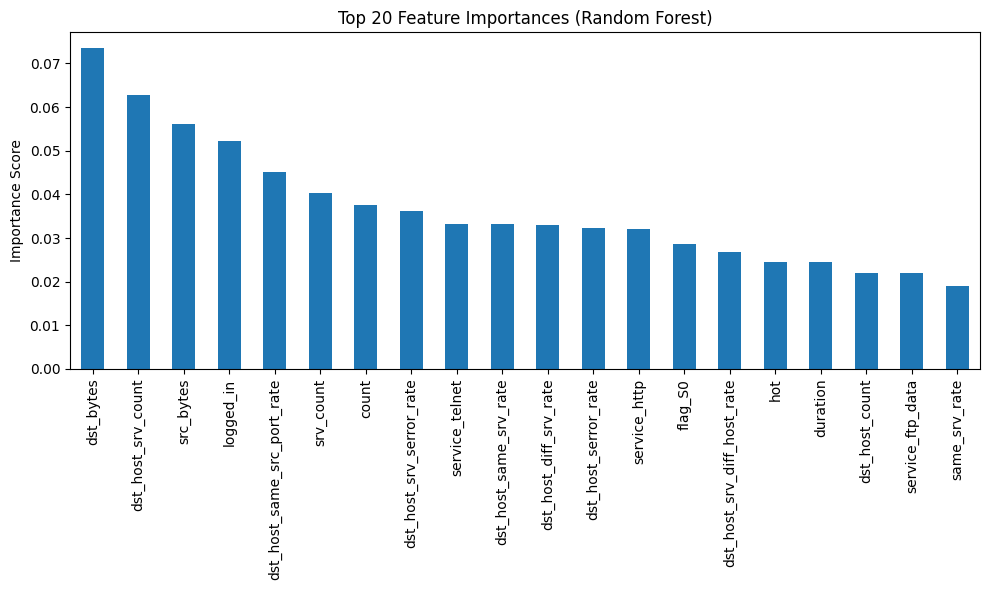

In [9]:
# Feature importance via Random Forest
print('Fitting RF for feature importance (this may take ~1 min)...')
rf_selector = RandomForestClassifier(n_estimators=100, random_state=SEED, n_jobs=-1)
rf_selector.fit(X_train_bal, y_train_bal)

importances = pd.Series(
    rf_selector.feature_importances_,
    index=feature_names
).sort_values(ascending=False)

print('\nTop 20 most important features:')
print(importances.head(20))

plt.figure(figsize=(10, 6))
importances.head(20).plot(kind='bar')
plt.title('Top 20 Feature Importances (Random Forest)')
plt.ylabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()

In [10]:
# Apply feature selection threshold
threshold = 0.001
selected_features = importances[importances >= threshold].index
dropped_features  = importances[importances < threshold].index

print(f'Features above threshold ({threshold}): {len(selected_features)}')
print(f'Features below threshold (dropped):     {len(dropped_features)}')

# Get column indices for selected features
selected_idx = [feature_names.index(f) for f in selected_features]

X_train_sel = X_train_bal[:, selected_idx]
X_test_sel  = X_test[:, selected_idx]

print(f'\nX_train after feature selection: {X_train_sel.shape}')
print(f'X_test after feature selection:  {X_test_sel.shape}')

Features above threshold (0.001): 48
Features below threshold (dropped):     74

X_train after feature selection: (336715, 48)
X_test after feature selection:  (22073, 48)


## 7. Modeling

Four models are trained on the same processed dataset (`X_train_sel`, `y_train_bal`) and evaluated on the same test set (`X_test_sel`, `y_test`). Each model represents a different paradigm:

| Model | Paradigm | Multiclass | Interpretable |
|---|---|---|---|
| Random Forest | Bagging ensemble | Yes | Yes |
| XGBoost | Boosting ensemble | Yes | Yes |
| Isolation Forest | Unsupervised anomaly detection | No (binary) | Partial |
| MLP | Neural network | Yes | No |

For each model, we record: classification report, training time, and inference latency (ms per sample).

> **Note on Isolation Forest:** It is an unsupervised binary detector (normal vs. attack). Its metrics are not directly comparable to the 5-class models and are presented separately in the benchmark.

### 7.1 Random Forest

Random Forest trains 100 decision trees on random feature subsets (bagging). Final prediction is the majority vote across all trees. It is naturally interpretable through feature importances and handles non-linear decision boundaries well. It is expected to perform reasonably but may struggle on minority classes due to its democratic voting mechanism — rare classes tend to be outvoted.

In [11]:
print('Training Random Forest...')
start = time.time()

rf_model = RandomForestClassifier(n_estimators=100, random_state=SEED, n_jobs=-1)
rf_model.fit(X_train_sel, y_train_bal)

train_time_rf = time.time() - start
print(f'Training time: {train_time_rf:.2f}s')

start = time.time()
rf_preds = rf_model.predict(X_test_sel)
inference_time_rf = (time.time() - start) / len(X_test_sel) * 1000

print(f'Inference latency: {inference_time_rf:.4f} ms/sample')
print(f'\nClassification Report:')
print(classification_report(y_test, rf_preds, target_names=label_encoder.classes_))

Training Random Forest...
Training time: 29.34s
Inference latency: 0.0077 ms/sample

Classification Report:
              precision    recall  f1-score   support

         dos       0.96      0.83      0.89      7167
      normal       0.68      0.97      0.80      9711
       probe       0.82      0.67      0.74      2421
         r2l       0.90      0.02      0.04      2707
         u2r       0.62      0.07      0.13        67

    accuracy                           0.77     22073
   macro avg       0.80      0.51      0.52     22073
weighted avg       0.82      0.77      0.73     22073



### 7.2 XGBoost

XGBoost uses gradient boosting — trees are trained sequentially, each one correcting the errors of the previous one. This iterative focus on misclassified samples gives it a natural advantage over Random Forest on imbalanced datasets, as it repeatedly revisits minority class errors. It is expected to be the strongest performer on Macro F1.

In [12]:
print('Training XGBoost...')
start = time.time()

xgb_model = XGBClassifier(
    n_estimators=100, max_depth=6, learning_rate=0.1,
    random_state=SEED, n_jobs=-1, verbosity=0,
    eval_metric='mlogloss'
)
xgb_model.fit(X_train_sel, y_train_bal)

train_time_xgb = time.time() - start
print(f'Training time: {train_time_xgb:.2f}s')

start = time.time()
xgb_preds = xgb_model.predict(X_test_sel)
inference_time_xgb = (time.time() - start) / len(X_test_sel) * 1000

print(f'Inference latency: {inference_time_xgb:.4f} ms/sample')
print(f'\nClassification Report:')
print(classification_report(y_test, xgb_preds, target_names=label_encoder.classes_))

Training XGBoost...
Training time: 34.73s
Inference latency: 0.0043 ms/sample

Classification Report:
              precision    recall  f1-score   support

         dos       0.96      0.82      0.88      7167
      normal       0.72      0.97      0.82      9711
       probe       0.80      0.75      0.77      2421
         r2l       0.98      0.18      0.30      2707
         u2r       0.71      0.43      0.54        67

    accuracy                           0.80     22073
   macro avg       0.83      0.63      0.66     22073
weighted avg       0.84      0.80      0.77     22073



### 7.3 Isolation Forest

Isolation Forest is an unsupervised anomaly detection algorithm. It works by randomly partitioning the feature space — anomalies (attacks) are isolated in fewer splits than normal samples. It requires no labels during training, making it applicable in environments where labeled attack data is unavailable.

Since it produces binary output (normal vs. anomaly), it is evaluated separately on a binarized version of the test labels. Its metrics are **not directly comparable** to the 5-class models.

In [13]:
print('Training Isolation Forest...')
start = time.time()

iso_model = IsolationForest(n_estimators=100, random_state=SEED, n_jobs=-1, contamination='auto')
iso_model.fit(X_train_sel)

train_time_iso = time.time() - start
print(f'Training time: {train_time_iso:.2f}s')

start = time.time()
iso_preds_raw = iso_model.predict(X_test_sel)
inference_time_iso = (time.time() - start) / len(X_test_sel) * 1000

# Convert: -1 (anomaly) -> 1 (attack), 1 (normal) -> 0
iso_preds      = (iso_preds_raw == -1).astype(int)
y_test_binary  = (y_test != label_encoder.transform(['normal'])[0]).astype(int)

print(f'Inference latency: {inference_time_iso:.4f} ms/sample')
print(f'\nClassification Report (binary: normal vs attack):')
print(classification_report(y_test_binary, iso_preds, target_names=['normal', 'attack']))

Training Isolation Forest...
Training time: 0.81s
Inference latency: 0.0066 ms/sample

Classification Report (binary: normal vs attack):
              precision    recall  f1-score   support

      normal       0.50      0.99      0.66      9711
      attack       0.95      0.21      0.34     12362

    accuracy                           0.55     22073
   macro avg       0.72      0.60      0.50     22073
weighted avg       0.75      0.55      0.48     22073



### 7.4 MLP (Multi-Layer Perceptron)

A feedforward neural network with 3 hidden layers (256 → 128 → 64 → 5 output classes). Regularization techniques applied:
- **BatchNorm** after each linear layer — stabilizes training and acts as a mild regularizer
- **Dropout (0.3)** after each hidden layer — randomly disables 30% of neurons per forward pass, forcing robust feature learning
- **Class-weighted CrossEntropyLoss** — penalizes misclassification of minority classes more heavily
- **Early stopping (patience=10)** on validation Macro F1 — stops training when generalization stops improving, restoring the best weights
- **ReduceLROnPlateau** — halves the learning rate when validation F1 plateaus for 3 epochs

The MLP is expected to be competitive but slower than tree-based models. On tabular data, gradient boosting methods generally have a structural advantage over neural networks.

In [14]:
class IntrusionMLP(nn.Module):
    def __init__(self, input_dim, num_classes):
        super(IntrusionMLP, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        return self.network(x)


# Class weights — inverse frequency
class_counts = np.bincount(y_train_bal)
class_weights = 1.0 / class_counts
class_weights = class_weights / class_weights.sum()
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32)

# Datasets
X_train_tensor = torch.tensor(X_train_sel, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_bal.values, dtype=torch.long)
X_test_tensor  = torch.tensor(X_test_sel, dtype=torch.float32)
y_test_tensor  = torch.tensor(y_test.values, dtype=torch.long)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader  = DataLoader(train_dataset, batch_size=512, shuffle=True)

device    = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model     = IntrusionMLP(input_dim=X_train_sel.shape[1], num_classes=5).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor.to(device))
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', patience=3, factor=0.5)

print(f'Using device: {device}')
print(f'Model parameters: {sum(p.numel() for p in model.parameters()):,}')

Using device: cpu
Model parameters: 54,917


In [15]:
EPOCHS = 50
best_f1 = 0
patience = 10
patience_counter = 0
best_model_state = None
best_epoch = 0
history = {'train_loss': [], 'val_f1': []}

print('Training MLP...')
start = time.time()

for epoch in range(EPOCHS):
    model.train()
    epoch_loss = 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        loss = criterion(model(X_batch), y_batch)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader)
    history['train_loss'].append(avg_loss)

    model.eval()
    with torch.no_grad():
        logits    = model(X_test_tensor.to(device))
        val_preds = logits.argmax(dim=1).cpu().numpy()

    val_f1 = f1_score(y_test, val_preds, average='macro')
    history['val_f1'].append(val_f1)
    scheduler.step(val_f1)

    if val_f1 > best_f1:
        best_f1          = val_f1
        best_epoch       = epoch
        best_model_state = {k: v.clone() for k, v in model.state_dict().items()}
        patience_counter = 0
    else:
        patience_counter += 1

    if (epoch + 1) % 5 == 0:
        print(f'Epoch {epoch+1:02d}/{EPOCHS} | Loss: {avg_loss:.4f} | Val Macro-F1: {val_f1:.4f} | Best: {best_f1:.4f}')

    if patience_counter >= patience:
        print(f'\nEarly stopping at epoch {epoch+1}')
        break

train_time_mlp = time.time() - start
print(f'\nTraining time: {train_time_mlp:.2f}s')
print(f'Best Macro-F1: {best_f1:.4f} at epoch {best_epoch+1}')

# Save best weights
torch.save(best_model_state, 'mlp_best_weights.pth')
print('Best model weights saved to mlp_best_weights.pth')

Training MLP...
Epoch 05/50 | Loss: 0.0377 | Val Macro-F1: 0.6031 | Best: 0.6031
Epoch 10/50 | Loss: 0.0263 | Val Macro-F1: 0.5764 | Best: 0.6031
Epoch 15/50 | Loss: 0.0225 | Val Macro-F1: 0.5722 | Best: 0.6031

Early stopping at epoch 15

Training time: 208.52s
Best Macro-F1: 0.6031 at epoch 5
Best model weights saved to mlp_best_weights.pth


Inference latency: 0.0037 ms/sample

Classification Report:
              precision    recall  f1-score   support

         dos       0.97      0.86      0.91      7167
      normal       0.72      0.96      0.82      9711
       probe       0.84      0.68      0.75      2421
         r2l       0.96      0.18      0.30      2707
         u2r       0.15      0.45      0.23        67

    accuracy                           0.80     22073
   macro avg       0.73      0.63      0.60     22073
weighted avg       0.84      0.80      0.78     22073



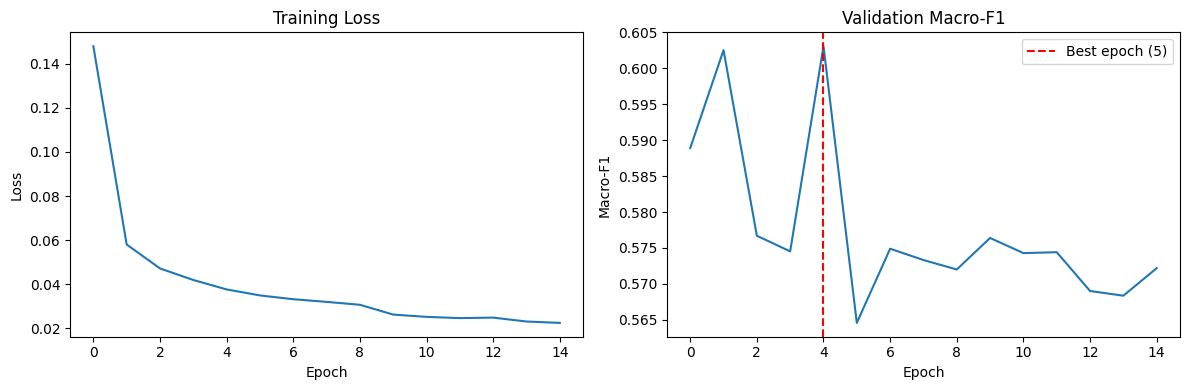

In [16]:
# Load best weights and evaluate
model.load_state_dict(best_model_state)
model.eval()

start = time.time()
with torch.no_grad():
    mlp_preds = model(X_test_tensor.to(device)).argmax(dim=1).cpu().numpy()
inference_time_mlp = (time.time() - start) / len(X_test_sel) * 1000

print(f'Inference latency: {inference_time_mlp:.4f} ms/sample')
print(f'\nClassification Report:')
print(classification_report(y_test, mlp_preds, target_names=label_encoder.classes_))

# Plot training history
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(history['train_loss'])
ax1.set_title('Training Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')

ax2.plot(history['val_f1'])
ax2.axvline(x=best_epoch, color='r', linestyle='--', label=f'Best epoch ({best_epoch+1})')
ax2.set_title('Validation Macro-F1')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Macro-F1')
ax2.legend()

plt.tight_layout()
plt.savefig('mlp_training_history.png', dpi=150)
plt.show()

## 8. Benchmark & Analysis

All models are compared on a unified benchmark table. 

### Why Macro F1 is the primary metric

Accuracy is a misleading metric for this dataset. Because `normal` and `dos` dominate the test set (76% combined), a model that ignores `u2r` and `r2l` entirely can still achieve ~76% accuracy. Macro F1 averages the F1 score across all 5 classes equally — a model that misses minority attack classes is penalized regardless of how well it handles the majority.

For a real intrusion detection system, **recall on attack classes is the most operationally important metric** — a missed attack is far more dangerous than a false alarm.

> **Note:** Isolation Forest metrics are binary (normal vs attack) and not directly comparable to the 5-class models. It is included to demonstrate the limitations of unsupervised detection.

                   Accuracy  Macro F1  Train Time (s)  Latency (ms) Interpretable
Model                                                                            
Random Forest        0.7743    0.5214         29.3405        0.0077           Yes
XGBoost              0.7979    0.6639         34.7301        0.0043           Yes
Isolation Forest*    0.5519    0.5020          0.8069        0.0066       Partial
MLP                  0.8022    0.6031        208.5244        0.0037            No


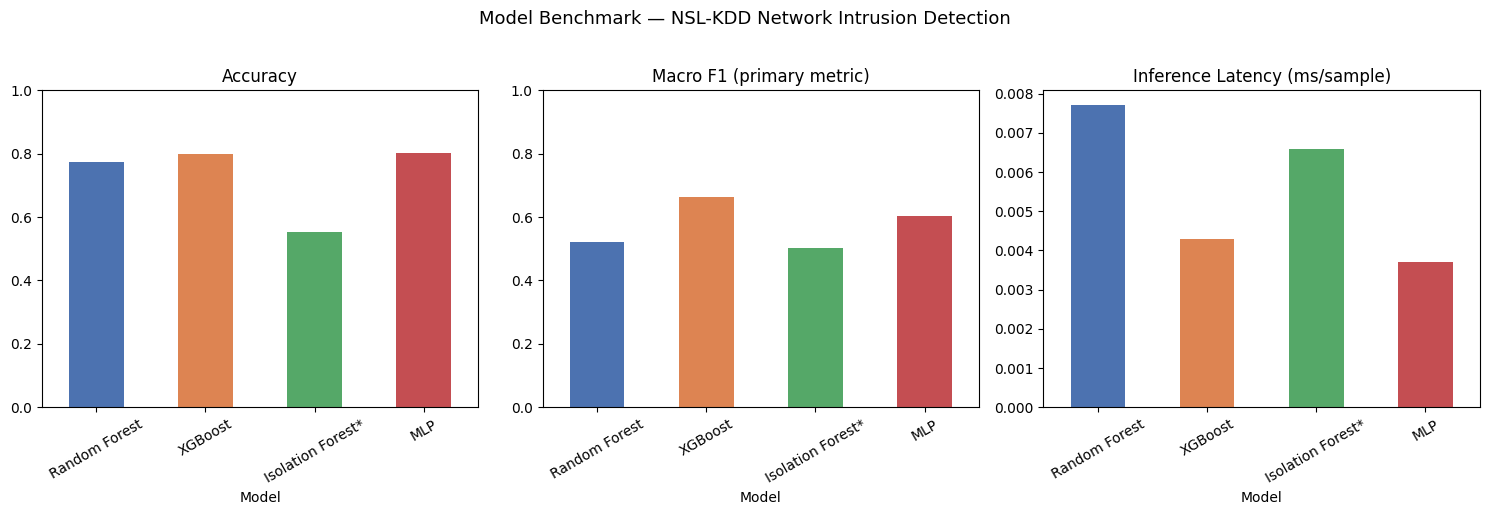


* Isolation Forest is binary (normal vs attack) — not directly comparable to 5-class models


In [17]:
results = {
    'Model':           ['Random Forest', 'XGBoost', 'Isolation Forest*', 'MLP'],
    'Accuracy':        [
        accuracy_score(y_test, rf_preds),
        accuracy_score(y_test, xgb_preds),
        accuracy_score(y_test_binary, iso_preds),
        accuracy_score(y_test, mlp_preds)
    ],
    'Macro F1':        [
        f1_score(y_test, rf_preds,  average='macro'),
        f1_score(y_test, xgb_preds, average='macro'),
        f1_score(y_test_binary, iso_preds, average='macro'),
        f1_score(y_test, mlp_preds, average='macro')
    ],
    'Train Time (s)':  [train_time_rf, train_time_xgb, train_time_iso, train_time_mlp],
    'Latency (ms)':    [inference_time_rf, inference_time_xgb, inference_time_iso, inference_time_mlp],
    'Interpretable':   ['Yes', 'Yes', 'Partial', 'No'],
}

benchmark = pd.DataFrame(results).set_index('Model')
benchmark = benchmark.round(4)
print(benchmark.to_string())

# Plot benchmark
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

benchmark['Accuracy'].plot(kind='bar', ax=axes[0], color=colors)
axes[0].set_title('Accuracy')
axes[0].set_ylim(0, 1)
axes[0].tick_params(axis='x', rotation=30)

benchmark['Macro F1'].plot(kind='bar', ax=axes[1], color=colors)
axes[1].set_title('Macro F1 (primary metric)')
axes[1].set_ylim(0, 1)
axes[1].tick_params(axis='x', rotation=30)

benchmark['Latency (ms)'].plot(kind='bar', ax=axes[2], color=colors)
axes[2].set_title('Inference Latency (ms/sample)')
axes[2].tick_params(axis='x', rotation=30)

plt.suptitle('Model Benchmark — NSL-KDD Network Intrusion Detection', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('benchmark.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n* Isolation Forest is binary (normal vs attack) — not directly comparable to 5-class models')

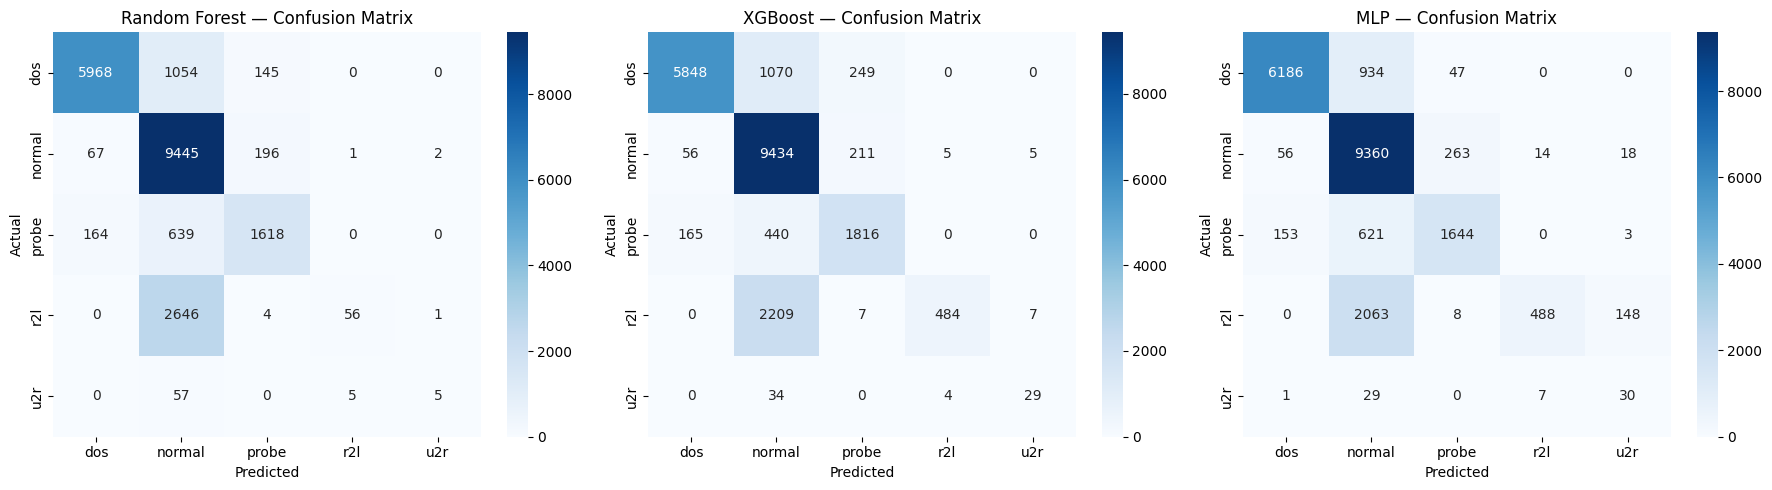

In [18]:
# Confusion matrices for the three multiclass models
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
class_names = label_encoder.classes_

for ax, preds, title in zip(
    axes,
    [rf_preds, xgb_preds, mlp_preds],
    ['Random Forest', 'XGBoost', 'MLP']
):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(
        cm, annot=True, fmt='d', ax=ax,
        xticklabels=class_names, yticklabels=class_names,
        cmap='Blues'
    )
    ax.set_title(f'{title} — Confusion Matrix')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150)
plt.show()

## 9. Conclusion

### Results Summary

**XGBoost achieved the best Macro F1** across all models, confirming that gradient boosting has a structural advantage on this tabular dataset. Its sequential error-correction mechanism naturally prioritizes misclassified minority class samples, giving it better recall on R2L and U2R attacks compared to Random Forest.

**The MLP achieved the highest accuracy** but lower Macro F1 than XGBoost — a direct illustration of why accuracy is insufficient as a metric for imbalanced classification. The MLP performed well on dominant classes (DoS, Normal) but was less consistent on minority classes. Training also took significantly longer with no performance gain over XGBoost.

**Isolation Forest demonstrated the limitation of unsupervised detection** — while it trains 20x faster than tree models and requires no labeled data, its attack recall of ~21% makes it unsuitable as a standalone detector. It confirms that labeled training data is essential for practical IDS.

### The U2R and R2L Problem

All models underperformed on U2R and R2L attacks — the most dangerous attack types in the dataset. U2R had only 52 training samples (0.04% of data), and even after SMOTE generated 67,291 synthetic samples, recall remained poor across all models. This is a fundamental data limitation, not a modeling failure. In practice, collecting more real U2R and R2L attack samples would be more impactful than further algorithm tuning.

### Limitations

- NSL-KDD is a benchmark dataset from 1999 network traffic — modern attack patterns differ significantly
- SMOTE-generated U2R samples may not reflect real attack behavior
- No hyperparameter optimization was performed (grid search or Bayesian optimization could improve all models)
- MLP architecture was not extensively tuned — more sophisticated approaches (residual connections, attention) may perform better

### Recommendation

For deployment in a real network intrusion detection system, **XGBoost is the recommended model** based on this benchmark — it achieves the best Macro F1, is interpretable through feature importances, trains in under a minute, and has sub-millisecond inference latency suitable for real-time packet classification.